# Demo: Agentic Real-Time Metadata Standardization

## Configurations

Before running this notebook, create a `.env` file in the project root with the following API keys:

```
OPENAI_API_KEY=your-openai-api-key          # Required — for LLM calls
CEDAR_API_KEY=your-cedar-api-key            # Required — for fetching CEDAR templates
BIOPORTAL_API_KEY=your-bioportal-api-key    # Required — for ontology term lookups

LANGSMITH_API_KEY=your-langsmith-api-key    # Optional — enables observability for LLM calls and agent runs
LANGSMITH_TRACING=true                      # Optional
LANGSMITH_PROJECT=my-project-name           # Optional
```

See [.env.example](../.env.example) for a template.

`DATA_ROOT` points to the root data directory. The evaluation functions expect the following directory structure underneath it:

```
DATA_ROOT/
├── schemas/
│   ├── atacseq.json              # JSON Schema for each assay type
│   ├── lcms.json
│   └── ...
├── atacseq/                      # One directory per assay type
│   ├── input/
│   │   ├── atacseq-<hash>.json   # Legacy metadata records (input)
│   │   └── ...
│   ├── gold/
│   │   ├── atacseq-<hash>.json   # Gold-standard reference outputs
│   │   └── ...
│   └── output/
│       └── <MODEL>/              # e.g., "gpt5mini"
│           ├── baseline/
│           │   ├── atacseq-<hash>.json   # Prompt-only LLM outputs
│           │   └── ...
│           └── experiment/
│               ├── atacseq-<hash>.json   # Tool-augmented agent outputs
│               └── ...
├── lcms/
│   ├── input/ ...
│   ├── gold/ ...
│   └── output/ ...
└── ...
```

Gold-standard and output files share the same filenames so that each output can be matched to its reference for evaluation.

In [1]:
DATA_ROOT = "../data"

`MODEL` specifies which LLM model was used for the migration run (e.g., `"gpt5mini"`).

In [2]:
MODEL = "gpt5mini"

`RUN_TYPE` selects which output set to evaluate — either `"baseline"` (prompt-only LLM) or `"experiment"` (tool-augmented agent). This determines which subdirectory under each assay is used when loading output files for comparison against the gold standard.

In [3]:
RUN_TYPE = "experiment"

## Run Experiments

Run the standardization agent on every assay type. The loop calls `run_experiment` once per assay, reading inputs from `DATA_ROOT/<assay>/input` and writing outputs to `DATA_ROOT/<assay>/output/<MODEL>/<RUN_TYPE>`.

In [21]:
RUN_EXPERIMENT = False  # Change to "True" to run the experiment. Be careful it costs money to run it!

In [22]:
# To run a single assay from the command line instead of bulk experiment:
# uv run python -m metadata_standardization_agent \
#     --input "data/atacseq/input" \
#     --target-schema "https://repo.metadatacenter.org/templates/dd5e8653-81cf-470b-b71b-15cab421bb84" \
#     --output "data/atacseq/output/gpt5mini/experiment" \
#     --model "gpt-5-mini" \
#     --concurrent 8 \
#     --experiment

if RUN_EXPERIMENT:
    from functools import partial
    from pathlib import Path

    from assays import ASSAY_SCHEMAS
    from evaluate import run_experiment

    if MODEL == "gpt41mini":
        gpt_model = "gpt-4.1-mini"
    elif MODEL == "gpt5mini":
        gpt_model = "gpt-5-mini"
    elif MODEL == "gpt5":
        gpt_model = "gpt-5"
    else:
        raise ValueError(f"Unknown model name: {MODEL}")

    if RUN_TYPE == "baseline":
        from baseline import build_baseline_workflow as build_workflow
        from baseline import build_user_prompt
    else:
        from experiment import build_experiment_workflow as build_workflow
        from experiment import build_user_prompt

    workflow_factory = partial(build_workflow, model=gpt_model)

    for assay, schema_iri in ASSAY_SCHEMAS.items():
        print(f"Running {RUN_TYPE} for {assay}...")
        run_experiment(
            template_iri=schema_iri,
            input_dir=Path(DATA_ROOT) / assay / "input",
            output_dir=Path(DATA_ROOT) / assay / "output" / MODEL / RUN_TYPE,
            workflow_factory=workflow_factory,
            user_prompt_builder=build_user_prompt,
            max_concurrency=8,
        )
else:
    print("Skipping experiment runs.")

Skipping experiment runs.


## Data Analysis

### 1. Per-Assay Accuracy Summary

`create_per_assay_accuracy_summary` iterates over all assay directories, calls `apply_metrics` on each gold-standard/output file pair within an assay, and averages the results to produce a mean accuracy per assay. The returned DataFrame contains three metric columns:

- **ontology_constrained_field_accuracy** — accuracy on fields whose values must come from a controlled ontology.
- **non_ontology_constrained_field_accuracy** — accuracy on free-text or non-ontology fields.
- **all_field_accuracy** — combined accuracy across all fields.

In [4]:
from data_analysis import create_per_assay_accuracy_summary

per_assay_df = create_per_assay_accuracy_summary(DATA_ROOT, MODEL, RUN_TYPE)
per_assay_df

,assay,ontology_constrained_field_accuracy,non_ontology_constrained_field_accuracy,all_field_accuracy
0,ATACseq,0.80,0.85,0.83
1,RNAseq,0.75,0.80,0.78
2,Auto-fluorescence,0.88,0.84,0.85
3,Cell DIVE,0.88,0.78,0.80
4,CODEX,0.82,0.77,0.79
5,Histology,0.76,0.76,0.76
6,IMC-2D,0.91,0.70,0.77
7,Lightsheet,1.00,0.79,0.86
8,MIBI,1.00,0.78,0.85
9,DESI,0.55,0.73,0.64


### 2. Overall Accuracy Summary

`create_overall_accuracy_summary` computes aggregate accuracy from raw counts rather than averaging ratios. It accumulates the number of correct and total fields across every gold-standard/output file pair from all assays, then divides once at the end to produce a single accuracy value. This avoids the bias that can arise from averaging per-file or per-assay ratios when sample sizes differ.

In [5]:
from data_analysis import create_overall_accuracy_summary

overall_df = create_overall_accuracy_summary(DATA_ROOT, MODEL, RUN_TYPE)
overall_df

,ontology_constrained_accuracy,non_ontology_constrained_accuracy,all_field_accuracy
0,0.78,0.79,0.79


### 3. Confidence Intervals and Significance Tests

`build_overall_table` and `build_per_assay_table` (from `significance.py`) compare the **baseline** (prompt-only LLM) against the **experiment** (tool-use agent, ARMS) on the same records. For each of the three field categories they report:

- **Bootstrap 95% confidence intervals** on accuracy — record-level for the per-assay table, and a record-level *cluster* bootstrap of the field-weighted accuracy for the pooled overall row (so the point estimates match Table 2).
- a **paired Wilcoxon signed-rank test** on per-record accuracy (`wilcoxon_p`).
- a **paired McNemar test** on per-field correctness, reporting `b` (fields only the baseline got right), `c` (fields only ARMS got right), and `mcnemar_p`.

These results do not depend on `RUN_TYPE`; both conditions are read directly from disk.

In [6]:
from significance import build_overall_table

# Pooled across all 839 records, one row per field category.
# Accuracy point estimates match the paper's Table 2 (bottom row); the CIs and
# p-values are the added uncertainty/significance reporting.
build_overall_table(DATA_ROOT, MODEL)

,category,n_records,n_fields,baseline,arms,wilcoxon_p,wilcoxon_n,mcnemar_b,mcnemar_c,mcnemar_p
0,Ontology-constrained,839,11434,"0.46 [0.45, 0.47]","0.78 [0.77, 0.79]",<0.001,828,345,3999,<0.001
1,Non-ontology-constrained,839,16823,"0.59 [0.58, 0.59]","0.79 [0.78, 0.79]",<0.001,829,564,3942,<0.001
2,All fields,839,28257,"0.54 [0.53, 0.54]","0.79 [0.78, 0.79]",<0.001,839,909,7941,<0.001


`plot_grouped_bar_chart` produces a side-by-side bar chart comparing **baseline** vs **ARMS** accuracy for a chosen metric across all assay types. Available metrics for the `metric` parameter:

- `ontology_constrained_field_accuracy`
- `non_ontology_constrained_field_accuracy`
- `all_field_accuracy`

By default (`error_mode="ci"`) the error bars show bootstrap 95% confidence intervals. Pass `error_mode="minmax"` for the per-record min/max range, or `show_error_bars=False` to hide them. Pass `save_path="figure.png"` to write the figure to a file instead of displaying it.

In [7]:
from significance import build_per_assay_table

# Per-assay accuracy with 95% CIs and significance, for a chosen field category:
# "ontology", "non_ontology", or "all".
build_per_assay_table(DATA_ROOT, MODEL, category="all")

,assay,n_records,baseline,arms,wilcoxon_p,mcnemar_b,mcnemar_c,mcnemar_p
0,ATACseq,100,"0.59 [0.58, 0.60]","0.83 [0.82, 0.83]",<0.001,218,1341,<0.001
1,RNAseq,100,"0.60 [0.59, 0.62]","0.78 [0.77, 0.79]",<0.001,301,1134,<0.001
2,Auto-fluorescence,100,"0.48 [0.47, 0.49]","0.85 [0.84, 0.86]",<0.001,48,941,<0.001
3,Cell DIVE,32,"0.59 [0.57, 0.61]","0.80 [0.78, 0.82]",<0.001,32,191,<0.001
4,CODEX,100,"0.59 [0.58, 0.60]","0.79 [0.78, 0.79]",<0.001,77,573,<0.001
5,Histology,77,"0.45 [0.44, 0.46]","0.76 [0.75, 0.77]",<0.001,50,743,<0.001
6,IMC-2D,13,"0.45 [0.42, 0.47]","0.77 [0.74, 0.81]",<0.001,5,107,<0.001
7,Lightsheet,9,"0.50 [0.46, 0.55]","0.86 [0.82, 0.89]",0.004,15,89,<0.001
8,MIBI,100,"0.59 [0.59, 0.60]","0.85 [0.84, 0.85]",<0.001,45,726,<0.001
9,DESI,15,"0.45 [0.44, 0.46]","0.64 [0.61, 0.66]",<0.001,20,107,<0.001


## Plots

In [8]:
from plots import plot_grouped_bar_chart

`plot_grouped_bar_chart` produces a side-by-side bar chart comparing **baseline** vs **experiment** accuracy for a chosen metric across all assay types. Available metrics for the `metric` parameter:

- `ontology_constrained_field_accuracy`
- `non_ontology_constrained_field_accuracy`
- `all_field_accuracy`

Set `show_error_bars=True` to display min/max error bars on each bar, showing the range of accuracy values within each assay.

### Ontology-Constrained Field Accuracy 

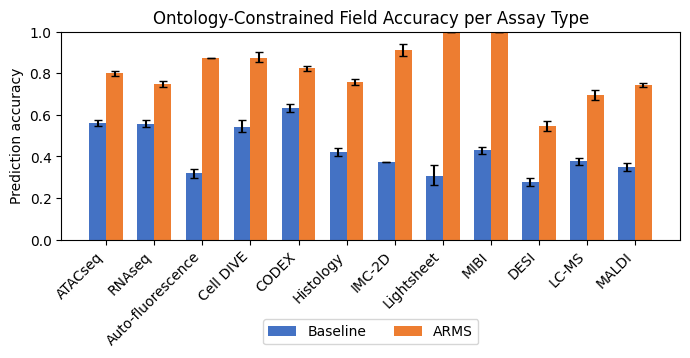

In [9]:
plot_grouped_bar_chart(
    DATA_ROOT,
    MODEL,
    metric="ontology_constrained_field_accuracy",
    title="Ontology-Constrained Field Accuracy per Assay Type",
)

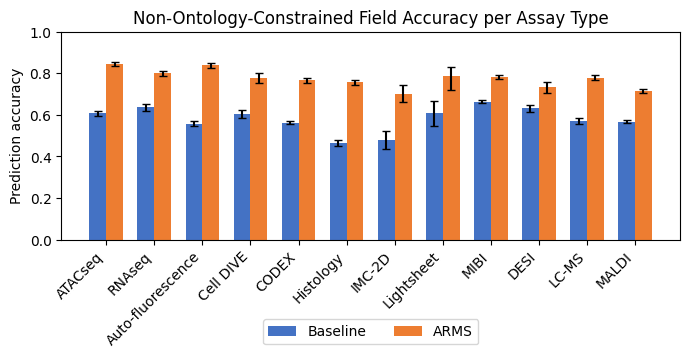

In [10]:
plot_grouped_bar_chart(
    DATA_ROOT,
    MODEL,
    metric="non_ontology_constrained_field_accuracy",
    title="Non-Ontology-Constrained Field Accuracy per Assay Type",
)

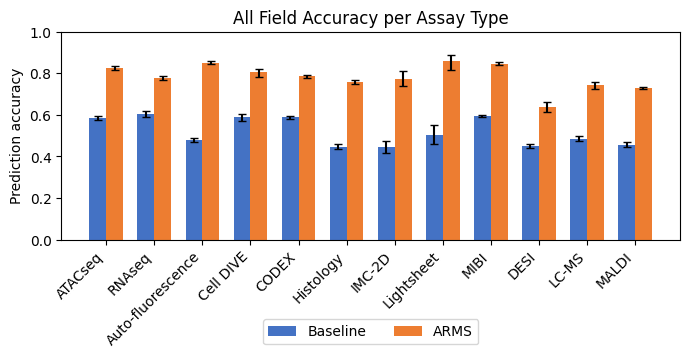

In [14]:
plot_grouped_bar_chart(
    DATA_ROOT,
    MODEL,
    metric="all_field_accuracy",
    title="All Field Accuracy per Assay Type",
)

### Error Cause Quantification

`error_causes.py` labels every prediction error by its likely **cause** and by its surface **error type**, separately for the baseline and ARMS. Causes include:

- `missing_ontology_result` — the agent searched BioPortal but received no candidates, so it kept the legacy value (ARMS only; requires `trace_dir`).
- `field_mapping_confusion` — the value was taken from a different, similarly named field.
- `external_information_required` — the gold value is absent from the legacy record (e.g., supplied from external protocol documents).
- `format_or_variant` — Boolean, DOI, delimiter/case, or numeric formatting differences.
- `other` — everything else (e.g., a wrong choice among returned ontology candidates).

`summarize_causes` groups errors by cause; `summarize_error_types` gives a finer breakdown by surface mechanism (e.g., separating Boolean and DOI failures).

In [11]:
from error_causes import build_error_detail, summarize_causes, summarize_error_types

# Set TRACE_DIR to the model's trace directory to enable the `missing_ontology_result`
# cause (scans the large trace files; takes a few minutes). Leave as None for a fast,
# offline run, in which those errors fall under `format_or_variant` or `other`.
TRACE_DIR = None  # e.g., f"../traces/{MODEL}"

baseline_detail = build_error_detail(DATA_ROOT, MODEL, "baseline")
arms_detail = build_error_detail(DATA_ROOT, MODEL, "experiment", trace_dir=TRACE_DIR)

print(f"Baseline errors: {len(baseline_detail)}  |  ARMS errors: {len(arms_detail)}")
summarize_causes(arms_detail)

Baseline errors: 13070  |  ARMS errors: 6038


,field_type,cause,count,pct_of_all_errors
0,ontology-constrained,other,1975,32.7
1,non-ontology-constrained,other,1532,25.4
2,non-ontology-constrained,field_mapping_confusion,1254,20.8
3,non-ontology-constrained,external_information_required,478,7.9
4,ontology-constrained,field_mapping_confusion,321,5.3
5,non-ontology-constrained,format_or_variant,283,4.7
6,ontology-constrained,format_or_variant,195,3.2


In [12]:
# Finer surface-mechanism breakdown, which separates Boolean (boolean_representation)
# and DOI (doi_format) failures that the coarser cause view groups under format_or_variant.
summarize_error_types(baseline_detail)

,field_type,error_type,count,pct_of_all_errors
0,ontology-constrained,wrong_value,3706,28.4
1,non-ontology-constrained,hallucinated_non_null,2017,15.4
2,non-ontology-constrained,wrong_value,1408,10.8
3,non-ontology-constrained,boolean_representation,1055,8.1
4,non-ontology-constrained,missed_non_null,971,7.4
5,non-ontology-constrained,doi_format,912,7.0
6,ontology-constrained,missed_non_null,793,6.1
7,ontology-constrained,hallucinated_non_null,746,5.7
8,ontology-constrained,delimiter_or_case,579,4.4
9,ontology-constrained,numeric_format_in_string,321,2.5


## Error Analysis

`create_error_report` aggregates field-level prediction errors into a summary report. It compares each output file against its gold standard, identifies every field where the predicted value differs from the expected value, and groups identical error patterns together. The returned DataFrame contains the following columns:

- **error_type** — the category of mismatch (e.g., wrong value, missing value).
- **field_type** — whether the field is ontology-constrained or non-ontology-constrained.
- **expected_value** — the field name and its gold-standard value.
- **predicted_value** — the field name and the value produced by the model.
- **frequency** — how many times this exact error pattern occurred across all samples.
- **assays** — which assay types exhibited this error.

In [15]:
from data_analysis import create_error_report

error_report_df = create_error_report(DATA_ROOT, MODEL, RUN_TYPE)
error_report_df

,error_type,field_type,expected_value,predicted_value,frequency,assays
0,wrong_value,ontology-constrained,analyte_class: Lipid,analyte_class: lipids,125,"desi, lcms, maldi"
1,delimiter_or_case,ontology-constrained,acquisition_instrument_model: Axio Scan.Z1,acquisition_instrument_model: AxioScan.Z1,114,"af, histology"
2,wrong_value,ontology-constrained,acquisition_instrument_model: NovaSeq 6000,acquisition_instrument_model: NovaSeq,102,"atacseq, rnaseq"
3,type_mismatch,non-ontology-constrained,roi_id: 1,roi_id: 1,100,mibi
4,wrong_value,ontology-constrained,preparation_instrument_vendor: Akoya Biosciences,preparation_instrument_vendor: CODEX,99,codex
...,...,...,...,...,...,...
350,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 5691,number_of_input_cells_or_nuclei: 880000,1,atacseq
351,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 6000,number_of_input_cells_or_nuclei: 1580000,1,atacseq
352,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 6167,number_of_input_cells_or_nuclei: 700000,1,atacseq
353,value_mismatch,non-ontology-constrained,number_of_input_cells_or_nuclei: 6500,number_of_input_cells_or_nuclei: 10600000,1,atacseq
